In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import pandas as pd

# HI

In [2]:
path = '/glade/work/acruz/Caribbean_Heat_data/ERA5/'
ds = xr.open_dataset(path+'dailymax_HI.nc')
ds

<xarray.Dataset> Size: 1GB
Dimensions:       (time: 31471, latitude: 82, longitude: 121)
Coordinates:
  * time          (time) datetime64[ns] 252kB 1940-01-01 ... 2026-02-28
  * latitude      (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude     (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    HI_daily_max  (time, latitude, longitude) float32 1GB ...

In [3]:
anom_ds= xr.open_dataset(path+'HI_dmax_month_anom.nc')
anom_ds

<xarray.Dataset> Size: 41MB
Dimensions:       (time: 1034, latitude: 82, longitude: 121)
Coordinates:
  * time          (time) datetime64[ns] 8kB 1940-01-31 1940-02-29 ... 2026-02-28
  * latitude      (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude     (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    HI_dmax_anom  (time, latitude, longitude) float32 41MB ...

In [4]:
d_ls = pd.date_range('2023-01-01', freq='D', end='2023-12-31')
d_ls

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10',
               ...
               '2023-12-22', '2023-12-23', '2023-12-24', '2023-12-25',
               '2023-12-26', '2023-12-27', '2023-12-28', '2023-12-29',
               '2023-12-30', '2023-12-31'],
              dtype='datetime64[us]', length=365, freq='D')

In [5]:
m_ls = pd.date_range('2023-01-16', freq='ME', end='2023-12-31')
m_ls

DatetimeIndex(['2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30',
               '2023-05-31', '2023-06-30', '2023-07-31', '2023-08-31',
               '2023-09-30', '2023-10-31', '2023-11-30', '2023-12-31'],
              dtype='datetime64[us]', freq='ME')

In [6]:
ds = ds.sel(time=d_ls, method='nearest')
ds

<xarray.Dataset> Size: 14MB
Dimensions:       (time: 365, latitude: 82, longitude: 121)
Coordinates:
  * time          (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
  * latitude      (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude     (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    HI_daily_max  (time, latitude, longitude) float32 14MB ...

In [7]:
m_hi_2023 = ds['HI_daily_max'].resample(time='ME').mean(dim='time').rename('monthly_mean_HI')
m_hi_2023

<xarray.DataArray 'monthly_mean_HI' (time: 12, latitude: 82, longitude: 121)> Size: 476kB
array([[[ 83.69704 ,  84.09559 ,  84.5541  , ...,  88.33192 ,
          87.409325,  84.70172 ],
        [ 83.50572 ,  84.18627 ,  84.79387 , ...,  87.691536,
          84.57939 ,  80.3661  ],
        [ 83.19566 ,  84.05632 ,  84.70857 , ...,  82.710175,
          80.62771 ,  81.18805 ],
        ...,
        [ 72.06918 ,  72.432594,  72.57692 , ...,  73.55922 ,
          73.52976 ,  73.50862 ],
        [ 71.78261 ,  72.002014,  72.06858 , ...,  73.3076  ,
          73.27375 ,  73.20795 ],
        [ 71.38745 ,  71.58569 ,  71.59651 , ...,  73.0538  ,
          73.00086 ,  72.909454]],

       [[ 84.968544,  85.794044,  86.416756, ...,  89.54116 ,
          88.58358 ,  86.08626 ],
        [ 82.79992 ,  84.27859 ,  85.63243 , ...,  88.792114,
          85.79719 ,  81.09889 ],
        [ 81.31172 ,  82.282295,  83.57311 , ...,  83.88529 ,
          81.16254 ,  81.472725],
...
        [ 75.77774 ,  75.63961 ,  75.433945, ...,  79.6188  ,
          79.55761 ,  79.55277 ],
        [ 75.32283 ,  75.08088 ,  74.94533 , ...,  79.361946,
          79.23123 ,  79.20083 ],
        [ 74.65369 ,  74.60159 ,  74.2435  , ...,  79.116776,
          78.90321 ,  78.78272 ]],

       [[ 90.34052 ,  90.60222 ,  90.78608 , ...,  98.2015  ,
          97.187126,  94.141945],
        [ 90.42202 ,  90.75957 ,  90.99476 , ...,  97.41976 ,
          93.606514,  88.771706],
        [ 90.42283 ,  90.705025,  90.93938 , ...,  91.737854,
          88.72392 ,  89.035706],
        ...,
        [ 71.31538 ,  71.17665 ,  70.954   , ...,  73.67033 ,
          73.6385  ,  73.68371 ],
        [ 70.528145,  70.496414,  70.314644, ...,  73.29477 ,
          73.32937 ,  73.37791 ],
        [ 69.84647 ,  69.84801 ,  69.7506  , ...,  73.04057 ,
          73.07855 ,  73.14145 ]]], shape=(12, 82, 121), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 96B 2023-01-31 2023-02-28 ... 2023-12-31
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

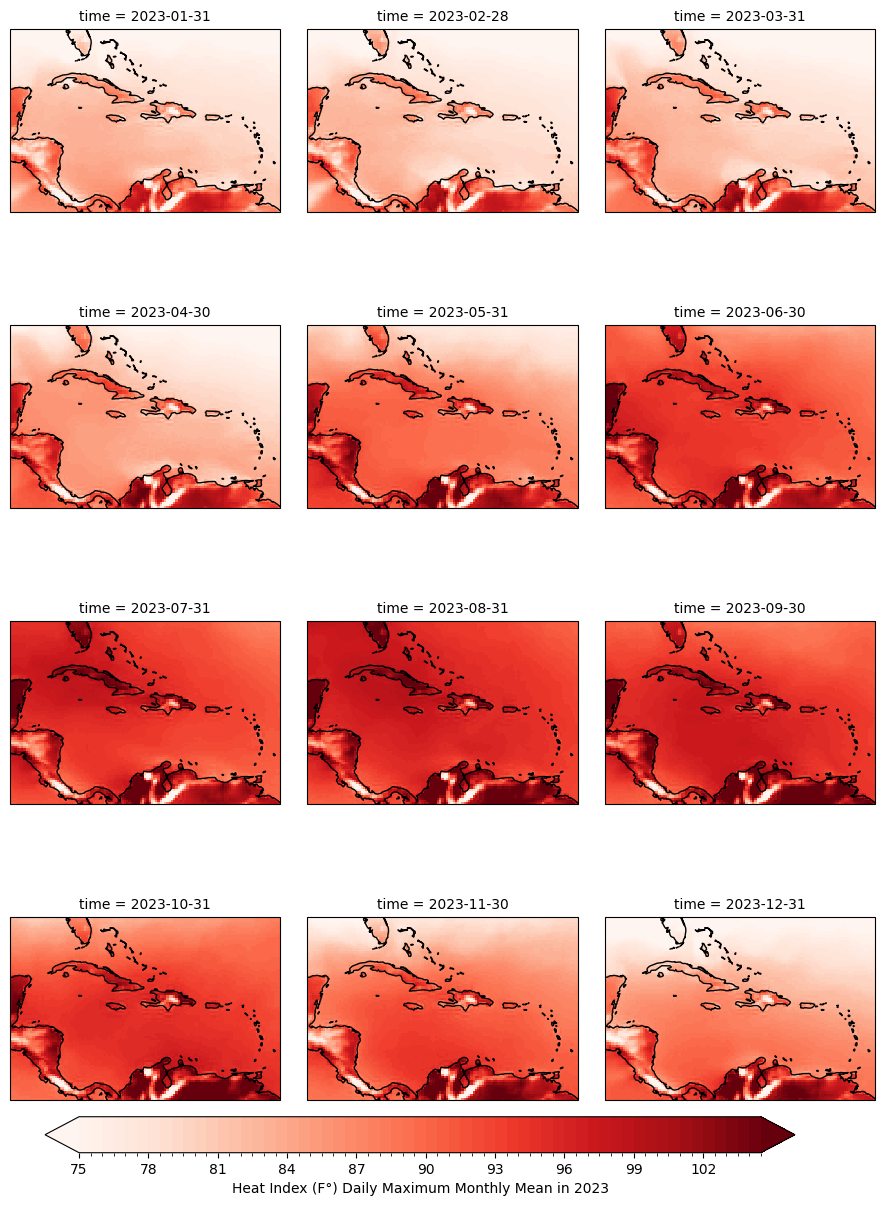

In [8]:
hi2023_plot = m_hi_2023.isel(time=np.arange(0, 12, 1)).plot(col='time',
                                                            col_wrap=3,
                                                            transform=ccrs.PlateCarree(),
                                                            cmap='Reds',
                                                            levels=np.arange(75, 105, 0.5),
                                                            subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)},
                                                            add_colorbar=False
                                                            )
cax = hi2023_plot.fig.add_axes([0.05, 0.01, 0.75, 0.03])
hi2023_plot.fig.colorbar(hi2023_plot.axs.flat[0].collections[0], cax=cax, label='Heat Index (F°) Daily Maximum Monthly Mean in 2023', orientation='horizontal')
hi2023_plot.map(lambda: plt.gca().coastlines())
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.88)

In [9]:
anom_ds

<xarray.Dataset> Size: 41MB
Dimensions:       (time: 1034, latitude: 82, longitude: 121)
Coordinates:
  * time          (time) datetime64[ns] 8kB 1940-01-31 1940-02-29 ... 2026-02-28
  * latitude      (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude     (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    HI_dmax_anom  (time, latitude, longitude) float32 41MB ...

In [10]:
anom2023_ds = anom_ds['HI_dmax_anom'].sel(time=m_ls, method='nearest')
anom2023_ds

<xarray.DataArray 'HI_dmax_anom' (time: 12, latitude: 82, longitude: 121)> Size: 476kB
[119064 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 96B 2023-01-31 2023-02-28 ... 2023-12-31
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

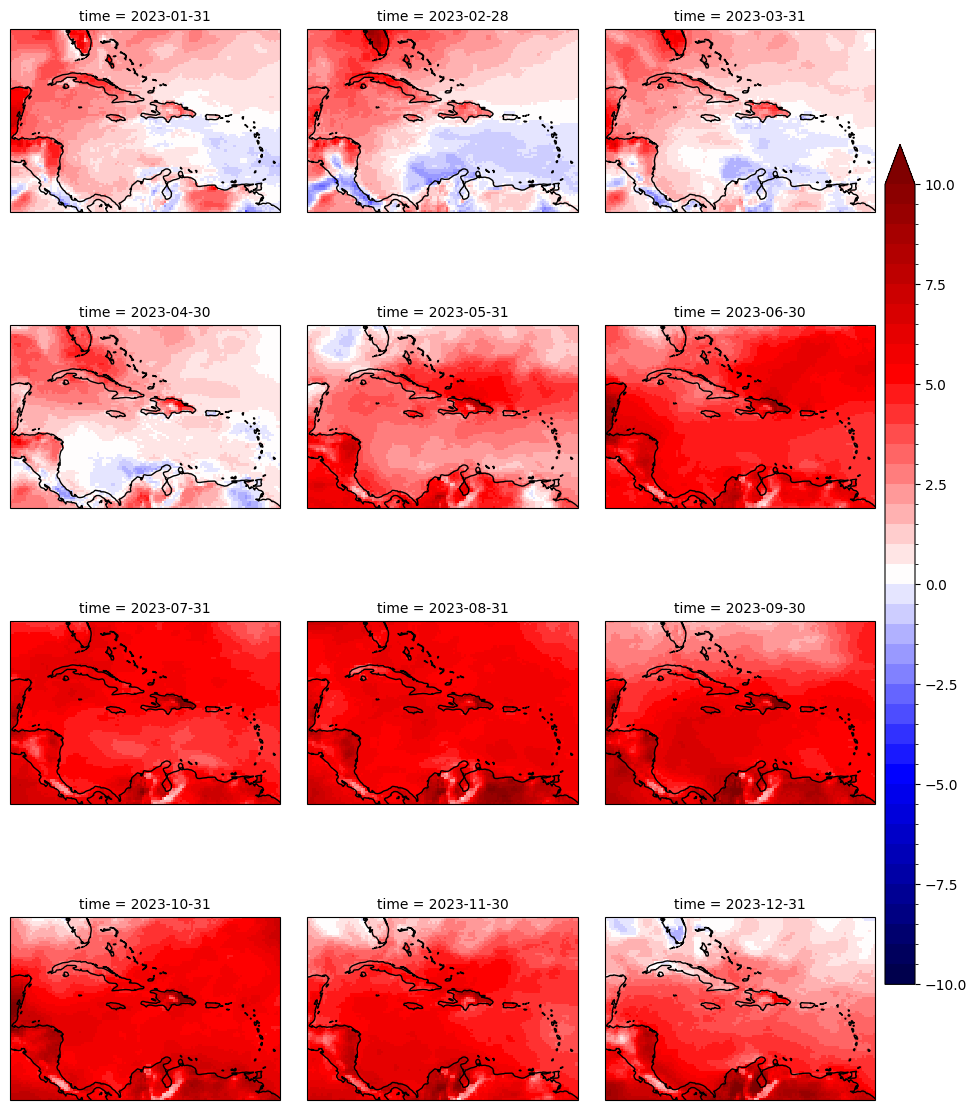

In [11]:
hi2023anom_plot = anom2023_ds.isel(time=np.arange(0, 12, 1)).plot(col='time',
                                                            col_wrap=3,
                                                            transform=ccrs.PlateCarree(),
                                                            cmap='seismic',
                                                            levels=np.arange(-10, 10.5, 0.5),
                                                            subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)},
                                                            add_colorbar=False
                                                            )
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.78)
cax = hi2023anom_plot.fig.add_axes([0.89, 0.15, 0.03, 0.7])
hi2023anom_plot.fig.colorbar(hi2023anom_plot.axs.flat[0].collections[0],cax=cax, label='', orientation='vertical')
hi2023anom_plot.map(lambda: plt.gca().coastlines())
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.88)

# Temp at peak time

In [12]:
tanom_peakHI = xr.open_dataset(path+'T_anom_during_peak_HI.nc')
tanom_peakHI

<xarray.Dataset> Size: 1GB
Dimensions:        (time: 31471, latitude: 82, longitude: 121)
Coordinates:
  * time           (time) datetime64[ns] 252kB 1940-01-01 ... 2026-02-28
  * latitude       (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude      (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    T_anom_HIdmax  (time, latitude, longitude) float32 1GB ...

In [13]:
tanom_peakHI_ME2023 = tanom_peakHI.sel(time=d_ls, method='nearest')
tanom_peakHI_ME2023

<xarray.Dataset> Size: 14MB
Dimensions:        (time: 365, latitude: 82, longitude: 121)
Coordinates:
  * time           (time) datetime64[ns] 3kB 2023-01-01 ... 2023-12-31
  * latitude       (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude      (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    T_anom_HIdmax  (time, latitude, longitude) float32 14MB ...

In [14]:
# mothly mean
tanom_peakHI_ME2023m = tanom_peakHI_ME2023['T_anom_HIdmax'].resample(time='ME').mean('time')
tanom_peakHI_ME2023m

<xarray.DataArray 'T_anom_HIdmax' (time: 12, latitude: 82, longitude: 121)> Size: 476kB
array([[[0.98751634, 1.0509574 , 1.0872852 , ..., 3.8522615 ,
         3.3665545 , 2.148911  ],
        [1.0018153 , 1.1089202 , 1.1790171 , ..., 3.5126972 ,
         2.1635783 , 0.7068442 ],
        [1.0094339 , 1.1581451 , 1.2421324 , ..., 1.4698851 ,
         0.7123561 , 0.7334447 ],
        ...,
        [3.1786175 , 3.313514  , 3.3543346 , ..., 1.603179  ,
         1.5790278 , 1.5655793 ],
        [3.3726246 , 3.442498  , 3.4341707 , ..., 1.6110653 ,
         1.592294  , 1.544284  ],
        [3.5185754 , 3.5813756 , 3.5492887 , ..., 1.6182921 ,
         1.5852553 , 1.5170327 ]],

       [[0.7988009 , 0.9599816 , 1.0835298 , ..., 4.1246567 ,
         3.7114727 , 2.5187771 ],
        [0.5259498 , 0.73491126, 0.9314248 , ..., 3.7909741 ,
         2.4412036 , 0.7899268 ],
        [0.31830487, 0.5337906 , 0.7197429 , ..., 1.7097658 ,
         0.7769427 , 0.770195  ],
...
        [1.825826  , 1.716101  , 1.6275401 , ..., 1.8869995 ,
         1.8410299 , 1.8353893 ],
        [1.8142191 , 1.7032145 , 1.6025157 , ..., 1.8714162 ,
         1.8386657 , 1.8363261 ],
        [1.7737579 , 1.68119   , 1.5013784 , ..., 1.8762736 ,
         1.8396138 , 1.8209361 ]],

       [[2.528403  , 2.6337645 , 2.6805549 , ..., 6.3965826 ,
         5.7033978 , 4.247344  ],
        [2.5522304 , 2.6466715 , 2.6745527 , ..., 5.7852645 ,
         4.0964503 , 2.1181247 ],
        [2.5426242 , 2.623931  , 2.685484  , ..., 3.2109237 ,
         2.1023204 , 2.027899  ],
        ...,
        [1.4190172 , 1.2934078 , 1.1932412 , ..., 0.7502609 ,
         0.7353949 , 0.7592281 ],
        [1.3630558 , 1.2996688 , 1.2180766 , ..., 0.67842644,
         0.6910489 , 0.71595615],
        [1.3465576 , 1.3100517 , 1.2155329 , ..., 0.67444146,
         0.6895841 , 0.7157691 ]]], shape=(12, 82, 121), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 96B 2023-01-31 2023-02-28 ... 2023-12-31
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

Text(0.5, 0.98, 'Monthly Mean Temperature Anomaly During Heat Index Daily Maximum')

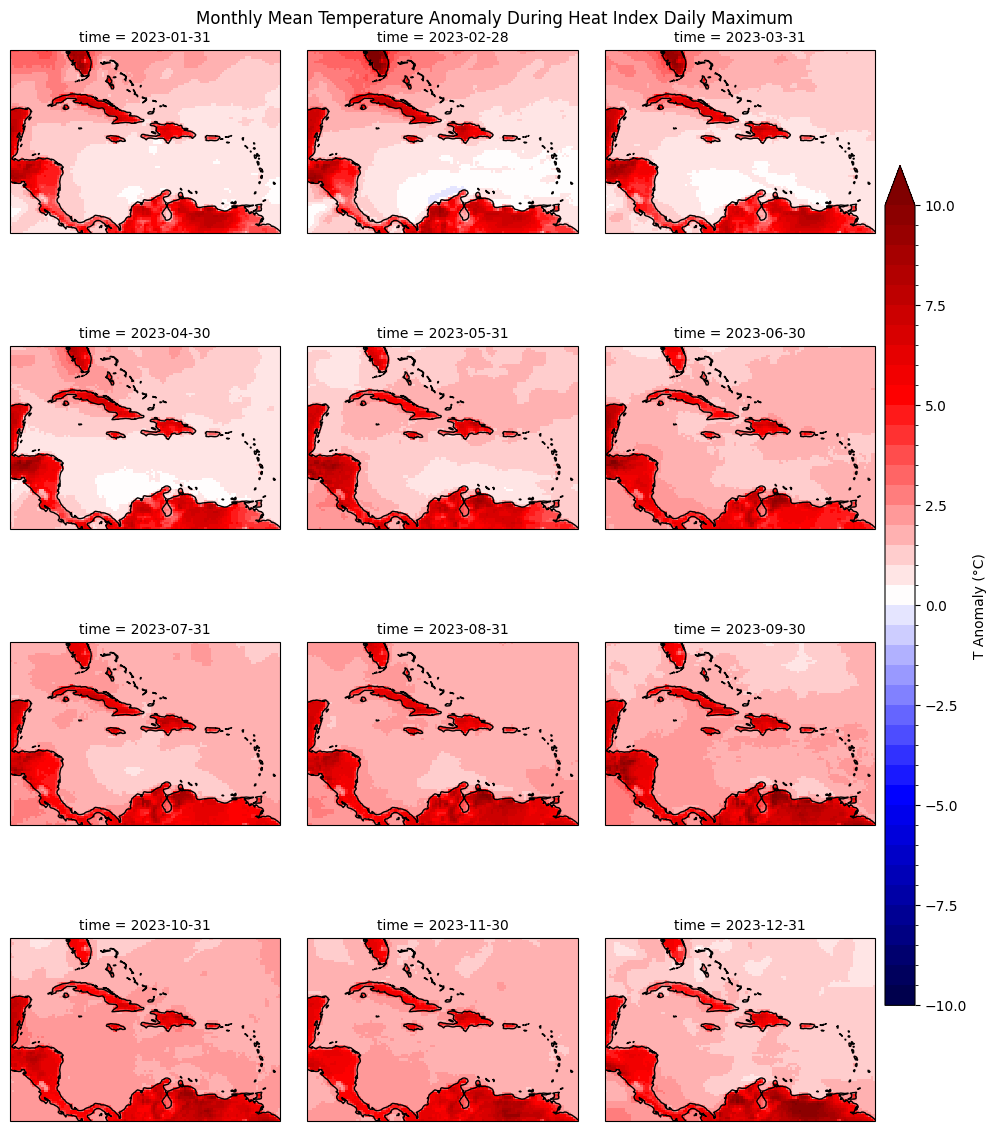

In [48]:
tp2023anom_plot = tanom_peakHI_ME2023m.isel(time=np.arange(0, 12, 1)).plot(col='time',
                                                            col_wrap=3,
                                                            transform=ccrs.PlateCarree(),
                                                            cmap='seismic',
                                                            levels=np.arange(-10, 10.5, 0.5),
                                                            subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)},
                                                            add_colorbar=False
                                                            )
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.78)
cax = tp2023anom_plot.fig.add_axes([0.89, 0.15, 0.03, 0.7])
tp2023anom_plot.fig.colorbar(tp2023anom_plot.axs.flat[0].collections[0],cax=cax, label='T Anomaly (°C)', orientation='vertical')
tp2023anom_plot.map(lambda: plt.gca().coastlines())
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.88)
tp2023anom_plot.fig.suptitle('Monthly Mean Temperature Anomaly During Heat Index Daily Maximum')

# RH at peak time

In [16]:
rhanom_peakHI = xr.open_dataset(path+'RH_anom_during_peak_HI.nc')
rhanom_peakHI

<xarray.Dataset> Size: 1GB
Dimensions:         (time: 31471, latitude: 82, longitude: 121)
Coordinates:
  * time            (time) datetime64[ns] 252kB 1940-01-01 ... 2026-02-28
  * latitude        (latitude) float64 656B 7.75 8.0 8.25 ... 27.5 27.75 28.0
  * longitude       (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    RH_anom_HIdmax  (time, latitude, longitude) float32 1GB ...

In [17]:
rhanom_peakHI2023 = rhanom_peakHI.sel(time=d_ls, method='nearest')
rhanom_peakHI2023

<xarray.Dataset> Size: 14MB
Dimensions:         (time: 365, latitude: 82, longitude: 121)
Coordinates:
  * time            (time) datetime64[ns] 3kB 2023-01-01 ... 2023-12-31
  * latitude        (latitude) float64 656B 7.75 8.0 8.25 ... 27.5 27.75 28.0
  * longitude       (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    RH_anom_HIdmax  (time, latitude, longitude) float32 14MB ...

In [18]:
rhanom_peakHI2023m = rhanom_peakHI2023['RH_anom_HIdmax'].resample(time='ME').mean('time')
rhanom_peakHI2023m

<xarray.DataArray 'RH_anom_HIdmax' (time: 12, latitude: 82, longitude: 121)> Size: 476kB
array([[[-1.3110701e+00, -1.5220901e+00, -1.6315310e+00, ...,
         -4.1023970e+00, -3.5608325e+00, -2.5909302e+00],
        [-1.1621898e+00, -1.4941857e+00, -1.6661665e+00, ...,
         -3.7967465e+00, -2.7973611e+00, -1.9026880e+00],
        [-1.1040890e+00, -1.4233218e+00, -1.6040175e+00, ...,
         -2.3875782e+00, -1.8955199e+00, -2.0274441e+00],
        ...,
        [ 1.6581258e-01, -1.7367972e-01, -4.7539520e-01, ...,
         -1.0459375e+00, -8.3340847e-01, -8.1650645e-01],
        [ 3.6062426e-03, -2.0621170e-01, -3.3583242e-01, ...,
         -1.1344209e+00, -1.1084777e+00, -8.4621108e-01],
        [-1.8805966e-02, -3.4396413e-01, -4.0684262e-01, ...,
         -1.1058593e+00, -1.0576042e+00, -6.6630232e-01]],

       [[-5.1580781e-01, -7.8967530e-01, -9.6745980e-01, ...,
         -4.4600554e+00, -4.1013155e+00, -2.9054227e+00],
        [-3.6664963e-02, -3.1533569e-01, -5.9677041e-01, ...,
         -4.2120748e+00, -2.9165654e+00, -1.9880568e+00],
        [ 1.3039589e-01, -1.9442150e-02, -2.0728193e-01, ...,
         -2.5604825e+00, -2.0890210e+00, -2.0474417e+00],
...
         -1.3028811e+00, -1.2103626e+00, -1.2512766e+00],
        [-2.8064829e-01, -3.5714951e-01, -2.9350612e-01, ...,
         -1.1822077e+00, -1.0472226e+00, -1.0526154e+00],
        [-8.2431287e-02, -2.2249807e-01,  1.4410552e-01, ...,
         -1.0305245e+00, -9.4232786e-01, -9.6649450e-01]],

       [[-1.6105735e+00, -1.8910589e+00, -2.0185306e+00, ...,
         -6.6168342e+00, -5.5742011e+00, -4.0151639e+00],
        [-1.6406620e+00, -1.8675646e+00, -1.8981493e+00, ...,
         -5.7496552e+00, -3.8672030e+00, -1.5635966e+00],
        [-1.6544785e+00, -1.7953211e+00, -1.9600382e+00, ...,
         -2.8855305e+00, -1.6081113e+00, -1.4271247e+00],
        ...,
        [-1.4138424e+00, -1.2124444e+00, -1.0378206e+00, ...,
         -1.6236459e+00, -1.6794751e+00, -1.7035985e+00],
        [-1.1325750e+00, -9.9740279e-01, -9.4471842e-01, ...,
         -1.6698264e+00, -1.5975585e+00, -1.6335188e+00],
        [-9.3420362e-01, -9.9441946e-01, -6.8653154e-01, ...,
         -1.5717963e+00, -1.6451488e+00, -1.6302962e+00]]],
      shape=(12, 82, 121), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 96B 2023-01-31 2023-02-28 ... 2023-12-31
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

Text(0.5, 0.98, 'Monthly Mean Relative Humidity Anomaly During Heat Index Daily Maximum')

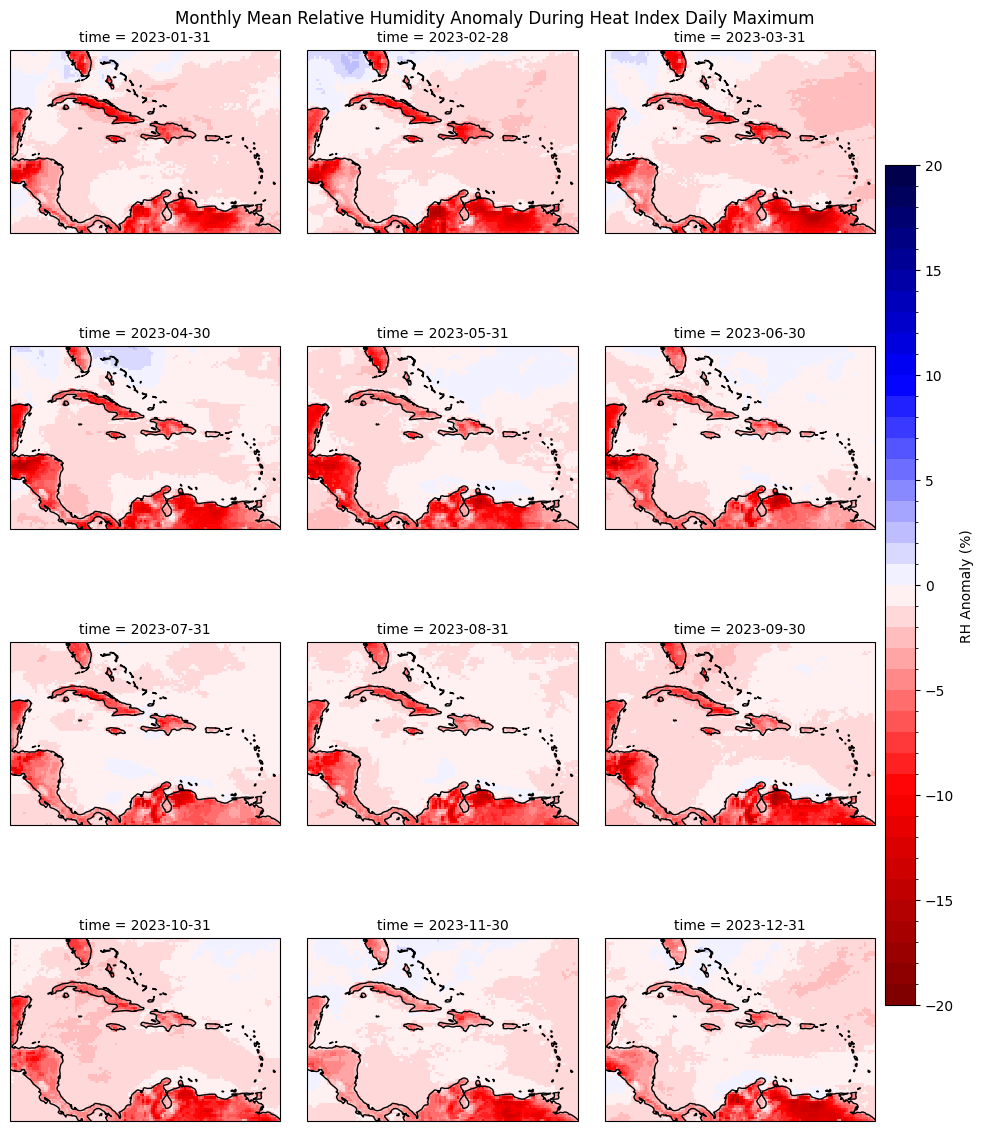

In [52]:
rhp2023anom_plot = rhanom_peakHI2023m.isel(time=np.arange(0, 12, 1)).plot(col='time',
                                                            col_wrap=3,
                                                            transform=ccrs.PlateCarree(),
                                                            cmap='seismic_r',
                                                            levels=np.arange(-20, 21, 1),
                                                            subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)},
                                                            add_colorbar=False
                                                            )
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.78)
cax = rhp2023anom_plot.fig.add_axes([0.89, 0.15, 0.03, 0.7])
rhp2023anom_plot.fig.colorbar(rhp2023anom_plot.axs.flat[0].collections[0],cax=cax, label='RH Anomaly (%)', orientation='vertical')
rhp2023anom_plot.map(lambda: plt.gca().coastlines())
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.88)
rhp2023anom_plot.fig.suptitle('Monthly Mean Relative Humidity Anomaly During Heat Index Daily Maximum')

# normal T anomaly ME mean

In [27]:
tanom_ds = xr.open_zarr(path+'ERA5_t_anom').sel(time=d_ls)
tanom_ds

<xarray.Dataset> Size: 14MB
Dimensions:    (time: 365, latitude: 82, longitude: 121)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
    month      (time) int64 3kB dask.array<chunksize=(365,), meta=np.ndarray>
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    VAR_2T     (time, latitude, longitude) float32 14MB dask.array<chunksize=(365, 82, 121), meta=np.ndarray>

In [28]:
tanom_dsMEm = tanom_ds['VAR_2T'].resample(time='ME').mean('time')
tanom_dsMEm

<xarray.DataArray 'VAR_2T' (time: 12, latitude: 82, longitude: 121)> Size: 476kB
dask.array<transpose, shape=(12, 82, 121), dtype=float32, chunksize=(12, 82, 121), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 96B 2023-01-31 2023-02-28 ... 2023-12-31
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

Text(0.5, 0.98, 'Temperature Anomaly Monthly Mean')

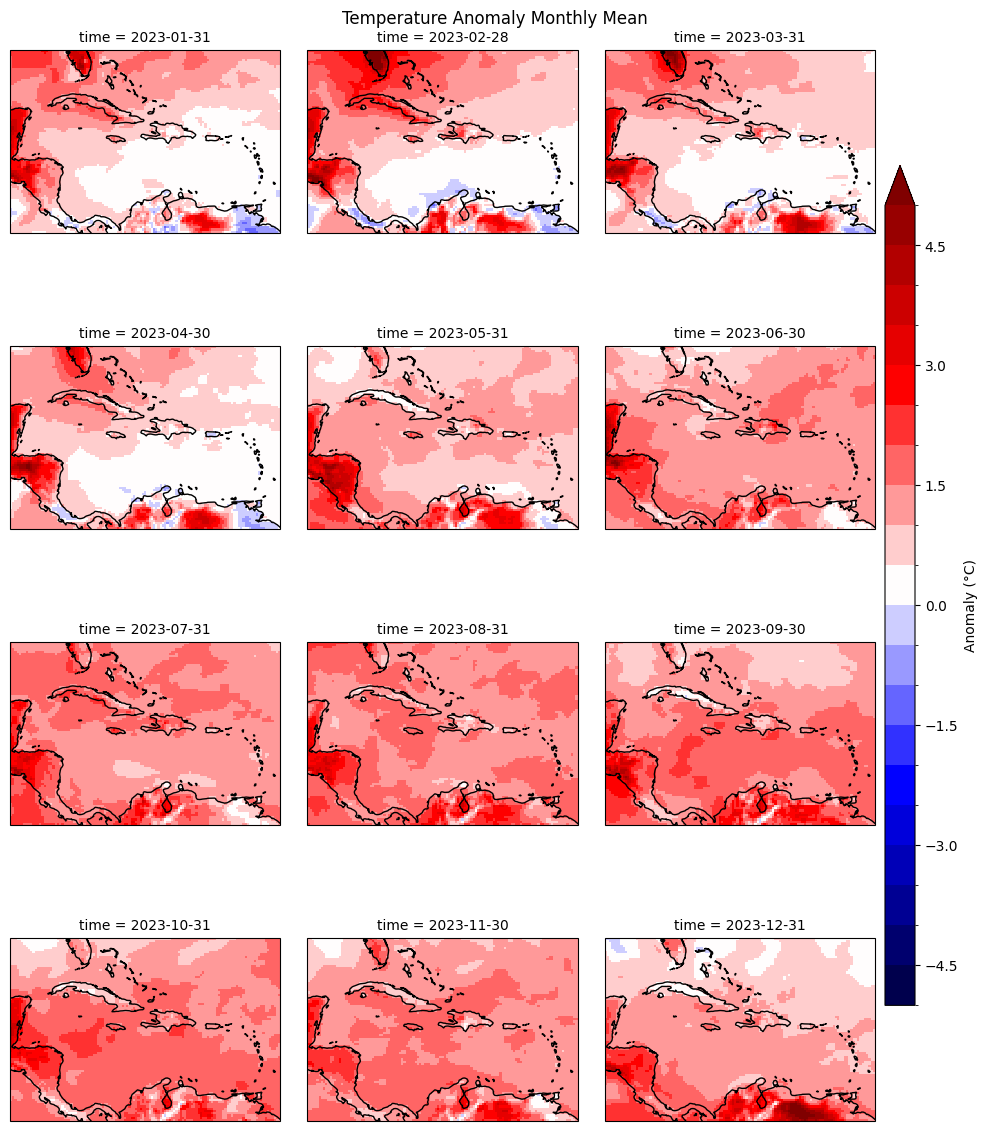

In [46]:
t2023anom_plot = tanom_dsMEm.isel(time=np.arange(0, 12, 1)).plot(col='time',
                                                            col_wrap=3,
                                                            transform=ccrs.PlateCarree(),
                                                            cmap='seismic',
                                                            levels=np.arange(-5, 5.5, 0.5),
                                                            subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)},
                                                            add_colorbar=False
                                                            )
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.78)
cax = t2023anom_plot.fig.add_axes([0.89, 0.15, 0.03, 0.7])
t2023anom_plot.fig.colorbar(t2023anom_plot.axs.flat[0].collections[0],cax=cax, label='Anomaly (°C)', orientation='vertical')
t2023anom_plot.map(lambda: plt.gca().coastlines())
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.88)
t2023anom_plot.fig.suptitle('Temperature Anomaly Monthly Mean')

# normal RH anomaly ME mean

In [32]:
rhanom = xr.open_zarr(path+'ERA5_rh_anom').sel(time=d_ls)
rhanom

<xarray.Dataset> Size: 14MB
Dimensions:                        (time: 365, latitude: 82, longitude: 121)
Coordinates:
  * time                           (time) datetime64[ns] 3kB 2023-01-01 ... 2...
    month                          (time) int64 3kB dask.array<chunksize=(365,), meta=np.ndarray>
  * latitude                       (latitude) float64 656B 7.75 8.0 ... 28.0
  * longitude                      (longitude) float64 968B -89.0 ... -59.0
Data variables:
    __xarray_dataarray_variable__  (time, latitude, longitude) float32 14MB dask.array<chunksize=(365, 82, 121), meta=np.ndarray>

In [37]:
rhanomMEm = rhanom['__xarray_dataarray_variable__'].resample(time='ME').mean('time')
rhanomMEm

<xarray.DataArray '__xarray_dataarray_variable__' (time: 12, latitude: 82,
                                                   longitude: 121)> Size: 476kB
dask.array<transpose, shape=(12, 82, 121), dtype=float32, chunksize=(12, 82, 121), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 96B 2023-01-31 2023-02-28 ... 2023-12-31
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

Text(0.5, 0.98, 'Relative Humidity Anomaly Monthly Mean')

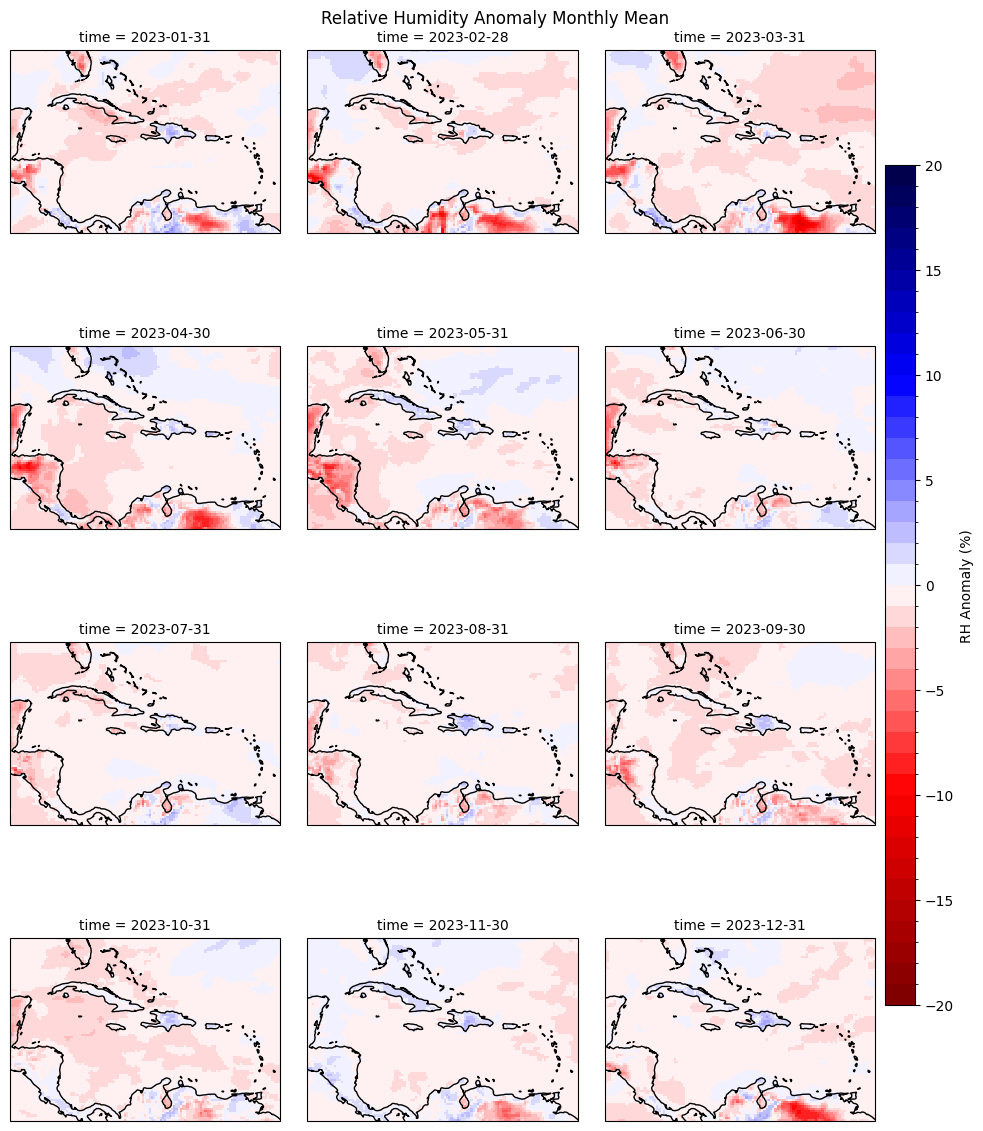

In [50]:
rh2023anom_plot = rhanomMEm.isel(time=np.arange(0, 12, 1)).plot(col='time',
                                                            col_wrap=3,
                                                            transform=ccrs.PlateCarree(),
                                                            cmap='seismic_r',
                                                            levels=np.arange(-20, 21, 1),
                                                            subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)},
                                                            add_colorbar=False
                                                            )
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.78)
cax = rh2023anom_plot.fig.add_axes([0.89, 0.15, 0.03, 0.7])
rh2023anom_plot.fig.colorbar(rh2023anom_plot.axs.flat[0].collections[0],cax=cax, label='RH Anomaly (%)', orientation='vertical')
rh2023anom_plot.map(lambda: plt.gca().coastlines())
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.88)
rh2023anom_plot.fig.suptitle('Relative Humidity Anomaly Monthly Mean')